In [66]:
import tensorflow as tf

In [67]:
import pandas as pd
import numpy as np

In [68]:
df_bon=pd.read_csv('true_mission.csv')
df_bon=df_bon.drop(columns=['ligne_id'])
df_mauvais=pd.read_csv('false_mission.csv')


In [69]:
df_merge = pd.concat([df_bon, df_mauvais], ignore_index=True)

In [70]:
df_merge.shape
df_merge.describe()


,mission_id,time,real_x,real_y,real_z,vx,vy,vz,ax,ay,...,pitch,yaw,wind_x,wind_y,wind_z,velocity,rain,fog,snow,is_attack
count,8358.000000,8.358000e+03,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,...,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,8358.000000,4872.000000,8358.000000
mean,199.814070,1.017322e+09,2.808266,3.333801,-2.473599,0.121052,0.330647,0.059781,-0.035117,-4.148440,...,-0.043150,0.705513,2.580058,1.373245,30.116819,306.757041,0.114997,0.125281,0.157483,0.469849
std,100.470163,8.605861e+08,68.286359,19.490086,4.478512,4.048098,1.228000,0.587196,0.501277,4.917100,...,1.420416,2.634619,0.562305,0.768751,99.327660,1201.462942,0.082570,0.103186,0.116119,0.499120
min,1.000000,-5.240803e+00,-809.051331,-10.475449,-23.077223,-50.758011,-4.529976,-4.942766,-6.627510,-17.565296,...,-3.141203,-3.141398,1.500410,0.400075,0.017362,0.089348,0.000000,0.000000,0.001000,0.000000
25%,125.000000,2.529400e+01,0.048300,-0.199479,-5.000000,-0.452107,-0.021111,-0.067717,-0.077596,-9.808188,...,-0.115835,-2.293691,2.104157,0.520053,0.473764,5.140000,0.050000,0.046000,0.073750,0.000000
50%,192.000000,1.744995e+09,5.000000,0.000000,-4.861824,0.011315,0.038289,-0.001955,-0.027815,-0.081253,...,0.000021,2.517266,2.656188,1.661395,0.549911,8.570000,0.101000,0.106500,0.135000,0.000000
75%,292.000000,1.745332e+09,12.175196,1.119969,-0.341277,0.679675,0.696052,0.054279,0.017166,-0.005464,...,0.035210,3.021319,3.059173,2.047710,17.483266,97.108687,0.160000,0.177000,0.196000,1.000000
max,363.000000,1.745538e+09,538.396240,253.241379,34.781960,29.395905,16.430178,5.235694,5.140120,8.111156,...,3.140979,3.499692,3.499864,2.499987,935.804447,18753.752602,0.400000,0.492000,0.500000,1.000000


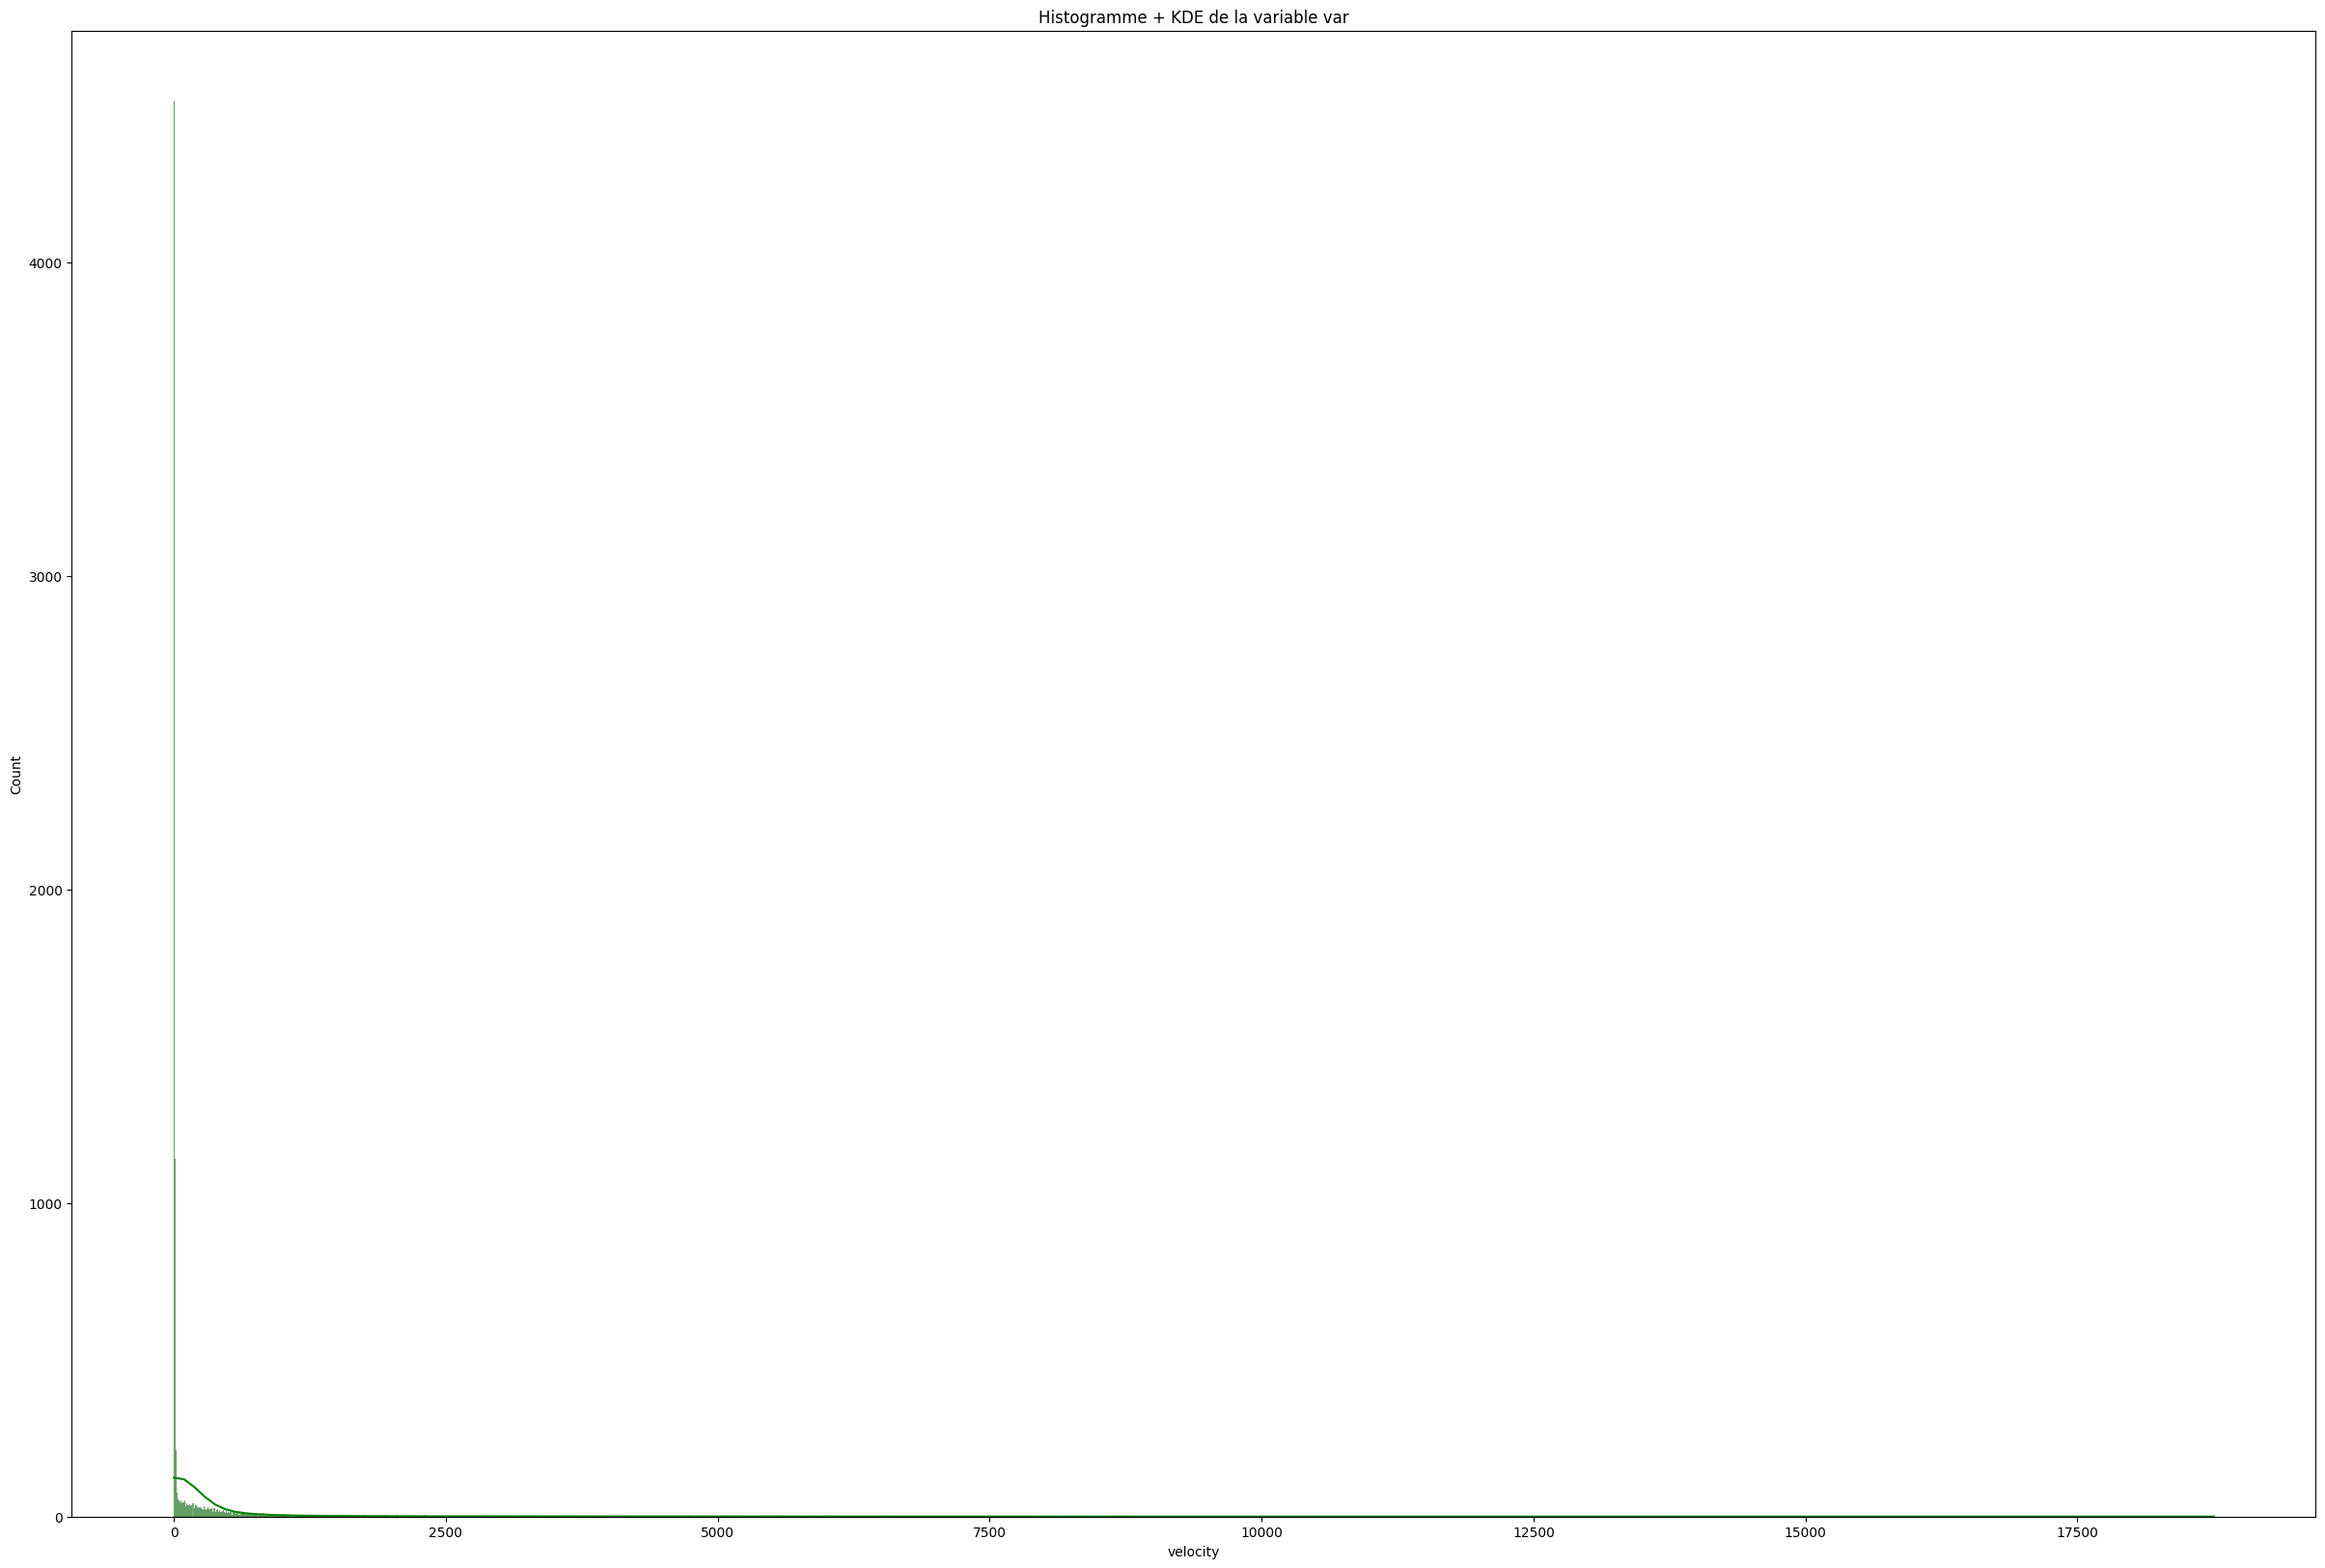

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(30,20))
sns.histplot(df_merge['velocity'], kde=True, color='green')
plt.title('Histogramme + KDE de la variable var')
plt.show()

In [72]:
seuil = 200
mediane = df_merge['velocity'].median()

df_merge.loc[df_merge['velocity'] > seuil, 'velocity'] = mediane

In [73]:
pourcentage = df_merge['is_attack'].value_counts(normalize=True) * 100
print(pourcentage)

is_attack
0.0    53.015075
1.0    46.984925
Name: proportion, dtype: float64


In [74]:
df_merge.shape

(8358, 22)

In [75]:
X=df_merge.drop(columns=['is_attack','snow'],axis=1)
Y=df_merge['is_attack']

In [76]:
nan_percent = df_merge.isna().mean() * 100
print(nan_percent)

mission_id     0.000000
time           0.000000
real_x         0.000000
real_y         0.000000
real_z         0.000000
vx             0.000000
vy             0.000000
vz             0.000000
ax             0.000000
ay             0.000000
az             0.000000
roll           0.000000
pitch          0.000000
yaw            0.000000
wind_x         0.000000
wind_y         0.000000
wind_z         0.000000
velocity       0.000000
rain           0.000000
fog            0.000000
snow          41.708543
is_attack      0.000000
dtype: float64


In [77]:
from sklearn.feature_selection import f_classif
import pandas as pd

 # binaire ou catégorielle

 #F, p = f_classif(X, Y)

#for i, col in enumerate(X.columns):
    #print(f"{col} → F-score : {F[i]:.2f}, p-value : {p[i]:.4f}")

In [78]:
from scipy.stats import pointbiserialr

for col in X.columns:
    corr, pval = pointbiserialr(X[col], Y)
    print(f"{col} → Corrélation point biserial : {corr:.4f}, p-value : {pval:.4f}")

mission_id → Corrélation point biserial : -0.3917, p-value : 0.0000
time → Corrélation point biserial : 0.7963, p-value : 0.0000
real_x → Corrélation point biserial : 0.1061, p-value : 0.0000
real_y → Corrélation point biserial : -0.1582, p-value : 0.0000
real_z → Corrélation point biserial : -0.4908, p-value : 0.0000
vx → Corrélation point biserial : -0.0135, p-value : 0.2181
vy → Corrélation point biserial : -0.2222, p-value : 0.0000
vz → Corrélation point biserial : 0.2932, p-value : 0.0000
ax → Corrélation point biserial : -0.0217, p-value : 0.0473
ay → Corrélation point biserial : 0.7918, p-value : 0.0000
az → Corrélation point biserial : -0.7766, p-value : 0.0000
roll → Corrélation point biserial : -0.0138, p-value : 0.2084
pitch → Corrélation point biserial : 0.0285, p-value : 0.0092
yaw → Corrélation point biserial : -0.5512, p-value : 0.0000
wind_x → Corrélation point biserial : 0.6943, p-value : 0.0000
wind_y → Corrélation point biserial : 0.7633, p-value : 0.0000
wind_z → Co

In [79]:
X=X.drop(columns=['vx','roll'])

IMPLEMENTATION D'UN RESEAUX DE NEURONES RECURRENTS

In [80]:

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate, Lambda
from tensorflow.keras.models import Model

# Hypothèses
timesteps = 21         # 21 étapes temporelles
features_per_step = 18 # Nombre de features à chaque step (ex: accéléro, gyro...)

# Entrée globale : séquence temporelle entière
# Shape = (21, 18)
features_input = Input(shape=(timesteps, features_per_step), name='X')

# Initialisation de l'activation h0 = 0 (batch_size, 1)
activation = Lambda(lambda x: tf.zeros_like(x[:, :1,0]))(features_input)
print(activation.shape)
# Boucle manuelle sur les 21 steps
for t in range(timesteps):
    # Extraire les features du pas t : x_t.shape = (batch_size, 18)
    step_features = Lambda(lambda x: x[:, t])(features_input) # (None, 1)
    
    combined_input = Concatenate(axis=1)([step_features, activation])  # (batch_size, 18+1)
    
    # Passer par une couche dense = "neurone" personnalisé
    neuron_output = Dense(1, activation='sigmoid', name=f'neuron_{t+1}')(combined_input)
    activation=neuron_output
    #activation = Lambda(lambda x: tf.expand_dims(x, axis=1))(neuron_output) 
   
    
    

final_output = Dense(1, activation='sigmoid')(activation)

# Construction du modèle
model = Model(inputs=features_input, outputs=final_output)

# Compilation
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # regression : MSE/MAE

# Résumé du modèle
model.summary()


(None, 1)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ X (InputLayer)      │ (None, 21, 18)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_67 (Lambda)  │ (None, 18)        │          0 │ X[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_66 (Lambda)  │ (None, 1)         │          0 │ X[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_63      │ (None, 19)        │          0 │ lambda_67[0][0],  │
│ (Concatenate)       │                   │            │ lambda_66[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_68 (Lambda)  │ (None, 18)        │          0 │ X[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neuron_1 (Dense)    │ (None, 1)         │         20 │ concatenate_63[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_64      │ (None, 19)        │          0 │ lambda_68[0][0],  │
│ (Concatenate)       │                   │            │ neuron_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_69 (Lambda)  │ (None, 18)        │          0 │ X[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neuron_2 (Dense)    │ (None, 1)         │         20 │ concatenate_64[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_65      │ (None, 19)        │          0 │ lambda_69[0][0],  │
│ (Concatenate)       │                   │            │ neuron_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_70 (Lambda)  │ (None, 18)        │          0 │ X[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neuron_3 (Dense)    │ (None, 1)         │         20 │ concatenate_65[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_66      │ (None, 19)        │          0 │ lambda_70[0][0],  │
│ (Concatenate)       │                   │            │ neuron_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_71 (Lambda)  │ (None, 18)        │          0 │ X[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neuron_4 (Dense)    │ (None, 1)         │         20 │ concatenate_66[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_67      │ (None, 19)        │          0 │ lambda_71[0][0],  │
│ (Concatenate)       │                   │            │ neuron_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_72 (Lambda)  │ (None, 18)        │          0 │ X[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neuron_5 (Dense)    │ (None, 1)         │         20 │ concatenate_67[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_68      │ (None, 19)        │          0 │ lambda_72[0][0],  │
│ (Concatenate)       │                   │            │ neuron_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_73 (Lambda)  │ (None, 18)        │          0 │ X[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neuron_6 (Dense)    │ (None, 1)         │         20 │ concatenate_68[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_69      │ (None, 19)        │          0 │ lambda_73[0][0],

 Total params: 422 (1.65 KB)

 Trainable params: 422 (1.65 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [82]:
X.shape

(8358, 18)

In [83]:

X = X_scaled.to_numpy()[:398 * 21].reshape(398, 21, 18)
print(X)

[[[-1.97895534e+00  8.45603248e-01 -4.11273135e-02 ...  1.99845858e-02
    2.96737676e+00 -7.68380710e-01]
  [-1.97895534e+00  8.45603249e-01 -1.18371348e-02 ...  1.99845858e-02
    2.96737676e+00 -7.68380710e-01]
  [-1.97895534e+00  8.45603250e-01  1.74530439e-02 ...  1.99845858e-02
    2.96737676e+00 -7.68380710e-01]
  ...
  [-1.97895534e+00  8.45603260e-01  1.74530439e-02 ...  1.99845858e-02
    2.96737676e+00 -7.68380710e-01]
  [-1.97895534e+00  8.45603260e-01 -1.18371348e-02 ...  1.99845858e-02
    2.96737676e+00 -7.68380710e-01]
  [-1.97895534e+00  8.45603261e-01 -4.11273135e-02 ...  1.99845858e-02
    2.96737676e+00 -7.68380710e-01]]

 [[-1.96900154e+00  8.45603263e-01 -4.11273135e-02 ... -1.20615396e-01
   -3.02760010e-01 -7.05700481e-02]
  [-1.96900154e+00  8.45603264e-01 -1.18371348e-02 ... -1.20615396e-01
   -3.02760010e-01 -7.05700481e-02]
  [-1.96900154e+00  8.45603264e-01  1.74530439e-02 ... -1.20615396e-01
   -3.02760010e-01 -7.05700481e-02]
  ...
  [-1.96900154e+00  8.4

In [84]:
nb_lignes = len(Y)
vol_length = 21
nb_vols = nb_lignes // vol_length
y = Y.to_numpy().reshape(nb_vols, 21)
y_vol = y[:, 0:1]
print(y_vol.shape)


(398, 1)


In [85]:
y = y_vol.reshape(-1, 1)
print(X.shape)


(398, 21, 18)


In [100]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [101]:
import numpy as np
import time

# Données fictives
        # Sortie attendue (ex : prédiction)

# Entraînement rapide
sart_time = time.time()
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)
end_time = time.time()


loss, accuracy = model.evaluate(X_test, y_test)
print("Training time : ",end_time - sart_time)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5944 - loss: 0.5636 - val_accuracy: 0.5469 - val_loss: 0.5631
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5743 - loss: 0.5687 - val_accuracy: 0.5469 - val_loss: 0.5576
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5915 - loss: 0.5682 - val_accuracy: 0.5469 - val_loss: 0.5524
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6169 - loss: 0.5638 - val_accuracy: 0.5781 - val_loss: 0.5475
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6183 - loss: 0.5509 - val_accuracy: 0.5781 - val_loss: 0.5427
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6320 - loss: 0.5689 - val_accuracy: 0.6094 - val_loss: 0.5381
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6715 - loss: 0.5402 - val_accuracy: 0.6250 - val_loss: 0.5337
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6909 - loss: 0.5179 - val_accuracy: 0.6406 - val_loss:

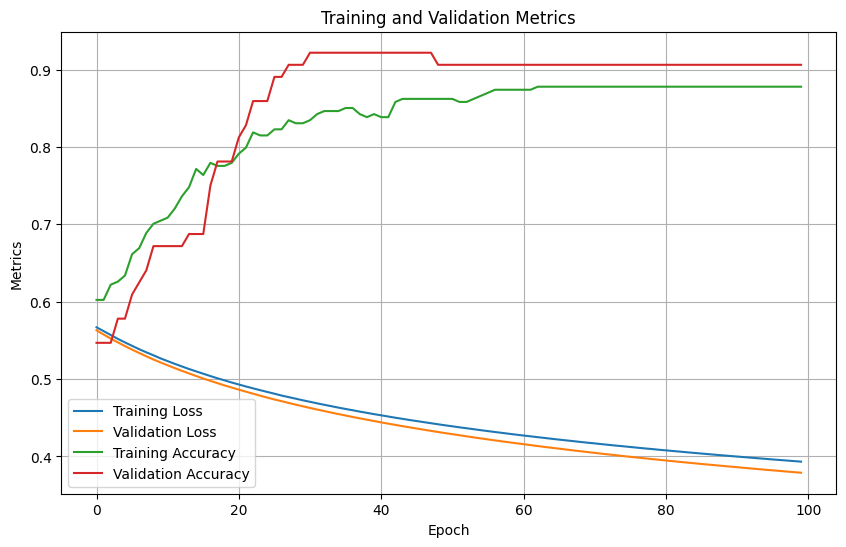

In [102]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.legend()
plt.grid(True)
plt.show()

In [103]:
y_pred_proba = model.predict(X_test)
y_pred_classes = (y_pred_proba > 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [104]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

         0.0       1.00      0.81      0.89        36
         1.0       0.86      1.00      0.93        44

    accuracy                           0.91        80
   macro avg       0.93      0.90      0.91        80
weighted avg       0.92      0.91      0.91        80



                                                     LSTM

In [105]:
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed, BatchNormalization
from tensorflow.keras.models import Sequential
model2 = Sequential([
    LSTM(units=14, input_shape=(21, 18), return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(units=7, return_sequences=False),
    Dropout(0.3),
    BatchNormalization(),
    Dense(units=1, activation='sigmoid')
])
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

sart_time = time.time()
history = model2.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

end_time = time.time()


loss, accuracy = model2.evaluate(X_test, y_test)
print("Training time : ",end_time - sart_time)

Epoch 1/100


c:\Users\NITRO\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.4920 - loss: 0.8791 - val_accuracy: 0.8125 - val_loss: 0.6167
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6039 - loss: 0.6534 - val_accuracy: 0.8750 - val_loss: 0.5768
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6517 - loss: 0.5950 - val_accuracy: 0.9062 - val_loss: 0.5400
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7306 - loss: 0.4972 - val_accuracy: 0.9062 - val_loss: 0.5077
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8045 - loss: 0.4804 - val_accuracy: 0.9062 - val_loss: 0.4802
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8409 - loss: 0.4229 - val_accuracy: 0.9062 - val_loss: 0.4532
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8059 - loss: 0.4069 - val_accuracy: 0.9062 - val_loss: 0.4294
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8545 - loss: 0.3629 - val_accuracy: 0.9062 - val_loss: 0.4109
Epoc

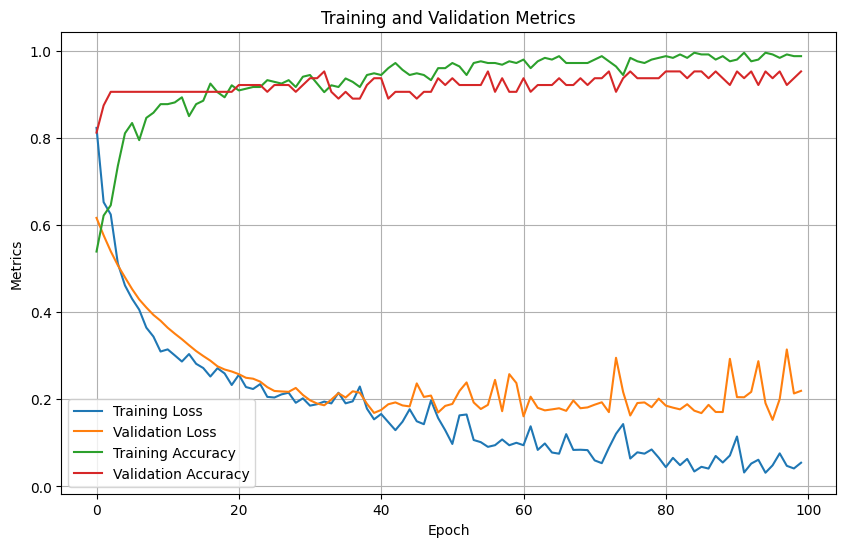

In [106]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.legend()
plt.grid(True)
plt.show()

In [107]:
y_pred_proba = model2.predict(X_test)
y_pred_classes = (y_pred_proba > 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


In [108]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred_classes))


              precision    recall  f1-score   support

         0.0       0.89      0.92      0.90        36
         1.0       0.93      0.91      0.92        44

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


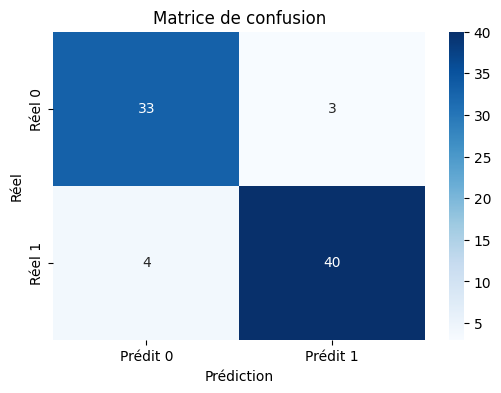

              precision    recall  f1-score   support

         0.0       0.89      0.92      0.90        36
         1.0       0.93      0.91      0.92        44

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



In [109]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Prédire les probabilités
y_pred_proba = model2.predict(X_test)

# 2. Convertir en classes (seuil = 0.5)
y_pred = (y_pred_proba > 0.5).astype(int)

# 3. Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# 4. Affichage
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Prédit 0", "Prédit 1"], yticklabels=["Réel 0", "Réel 1"])
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.show()

# 5. Rapport de classification
print(classification_report(y_test, y_pred))
